# Confidence Score vs. Calibration Quality

Does DiffDock's confidence score correlate with how well-calibrated the pose distribution is?

Complexes are grouped by **rank-1 confidence score** and compared on two benchmarks side by side:
- **PDBBind test set** (322 complexes, 40 samples each)
- **PoseBusters benchmark** (305 complexes, 40 samples each)

Metrics:
- **MIRA score** — how well the crystal pose is covered by the predicted distribution (ref ≈ 0.683 for S=40)
- **TARP ECP** — over-dispersed (above diagonal) or mode-collapsed (below diagonal)
- **Top-1 RMSD accuracy**

Confidence thresholds (README): **High** c > 0, **Moderate** −1.5 < c ≤ 0, **Low** c ≤ −1.5.
Only complexes with ≥ 15 loadable poses are included. All MIRA/TARP values are pre-computed — no heavy computation runs here.

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import mannwhitneyu, theilslopes

matplotlib.rcParams['figure.dpi'] = 120

from molcalib.tarp import ecp_from_fractions, plot_ecp, bootstrap_ecp
from molcalib.mira import mira_null

PDB_METRICS = '/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics'
PB_METRICS  = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics'
FIGURES     = "/home/qf226/MProject/thesis/figures/confidence_calibration"
os.makedirs(FIGURES, exist_ok=True)

## 1. Load Pre-Computed Data

In [2]:
def load_dataset(metrics_dir, label):
    """Load all pre-computed arrays for one benchmark."""
    d = {}
    d['label']       = label
    d['names']       = np.load(f'{metrics_dir}/complex_names.npy',   allow_pickle=True)
    d['conf_raw']    = np.load(f'{metrics_dir}/confidences.npy')        # (N, 40) generation order
    d['rmsds_raw']   = np.load(f'{metrics_dir}/rmsds.npy')              # (N, 40)
    d['top1_rmsd']   = np.load(f'{metrics_dir}/top1_rmsd.npy')          # (N,)
    d['tarp_fracs']  = np.load(f'{metrics_dir}/tarp_fractions_centroid.npy')  # (N, K)
    mira_names       = np.load(f'{metrics_dir}/mira_names_symrmsd.npy', allow_pickle=True)
    mira_scores_raw  = np.load(f'{metrics_dir}/mira_scores_symrmsd.npy')
    mira_map         = dict(zip(mira_names, mira_scores_raw))
    d['mira_scores'] = np.array([mira_map.get(n, np.nan) for n in d['names']])
    N = len(d['names'])
    print(f"{label}: {N} complexes, "
          f"conf sentinels={int((d['conf_raw'] == -1000).sum())}, "
          f"MIRA NaN={int(np.isnan(d['mira_scores']).sum())}, "
          f"TARP shape={d['tarp_fracs'].shape}")
    return d

PDB = load_dataset(PDB_METRICS, 'PDBBind')
PB  = load_dataset(PB_METRICS,  'PoseBusters')
DATASETS = [PDB, PB]

PDBBind: 322 complexes, conf sentinels=78, MIRA NaN=0, TARP shape=(322, 100)
PoseBusters: 305 complexes, conf sentinels=31, MIRA NaN=0, TARP shape=(305, 100)


## 2. Sort by Confidence, Filter, and Assign Groups

Confidence values are stored in **generation order**. We sort descending so rank-1 = `conf_ranked[:, 0]`.
Sentinel −1000 is treated as −∞ during sorting (missing poses go to the end).

| Group    | Criterion        |
|----------|------------------|
| High     | rank-1 c > 0     |
| Moderate | −1.5 < rank-1 c ≤ 0 |
| Low      | rank-1 c ≤ −1.5  |

In [3]:
MIN_SAMPLES = 15

GROUPS = [
    ('High',     lambda c: c > 0,                    'C2'),
    ('Moderate', lambda c: (c > -1.5) & (c <= 0),    'C1'),
    ('Low',      lambda c: c <= -1.5,                'C3'),
]
GROUP_NAMES  = [g[0] for g in GROUPS]
GROUP_COLORS = {g[0]: g[2] for g in GROUPS}
REF_40 = mira_null(S=40)

def process_dataset(d):
    """Add rank-ordered arrays, loadable count, group masks to dataset dict."""
    N    = len(d['names'])
    conf = np.where(d['conf_raw'] == -1000, -np.inf, d['conf_raw'].astype(float))
    order            = np.argsort(-conf, axis=1)
    conf_r           = conf[np.arange(N)[:, None], order]
    conf_r           = np.where(np.isneginf(conf_r), np.nan, conf_r)
    d['conf_ranked'] = conf_r
    d['rmsds_ranked']= d['rmsds_raw'][np.arange(N)[:, None], order]
    d['rank1_conf']  = conf_r[:, 0]
    d['n_loadable']  = (d['conf_raw'] != -1000).sum(axis=1)
    d['mask_keep']   = (d['n_loadable'] >= MIN_SAMPLES) & np.isfinite(d['rank1_conf'])
    d['group_masks'] = {}
    for name, fn, _ in GROUPS:
        d['group_masks'][name] = d['mask_keep'] & fn(d['rank1_conf'])
    return d

for d in DATASETS:
    process_dataset(d)

print(f'Reference MIRA (S=40): {REF_40:.4f}\n')
for d in DATASETS:
    print(f"{d['label']} — filtered: {d['mask_keep'].sum()}")
    print(f"  {'Group':<12} {'N':>4}  {'Rank-1 conf (med)':>18}  {'MIRA mean':>10}")
    for name, fn, _ in GROUPS:
        m = d['group_masks'][name]
        c_med = np.nanmedian(d['rank1_conf'][m])
        mira_mean = np.nanmean(d['mira_scores'][m])
        print(f"  {name:<12} {m.sum():>4}  {c_med:>18.3f}  {mira_mean:>10.4f}")
    print()

Reference MIRA (S=40): 0.6833

PDBBind — filtered: 321
  Group           N   Rank-1 conf (med)   MIRA mean
  High           90               0.279      0.6351
  Moderate      197              -0.560      0.6131
  Low            34              -1.778      0.6325

PoseBusters — filtered: 305
  Group           N   Rank-1 conf (med)   MIRA mean
  High          122               0.285      0.6360
  Moderate      168              -0.529      0.6280
  Low            15              -1.869      0.6260



## 3. MIRA Score by Confidence Group

**MIRA** reference for S=40 ≈ 0.683. Scores below this indicate mode collapse (crystal pose falls outside the predicted distribution).

PDBBind — Mann-Whitney U (one-sided, group > rest):
  High > rest: p=3.396e-02
  Moderate > rest: p=9.867e-01
  Low > rest: p=2.004e-01

PoseBusters — Mann-Whitney U (one-sided, group > rest):
  High > rest: p=2.466e-01
  Moderate > rest: p=7.228e-01
  Low > rest: p=5.780e-01



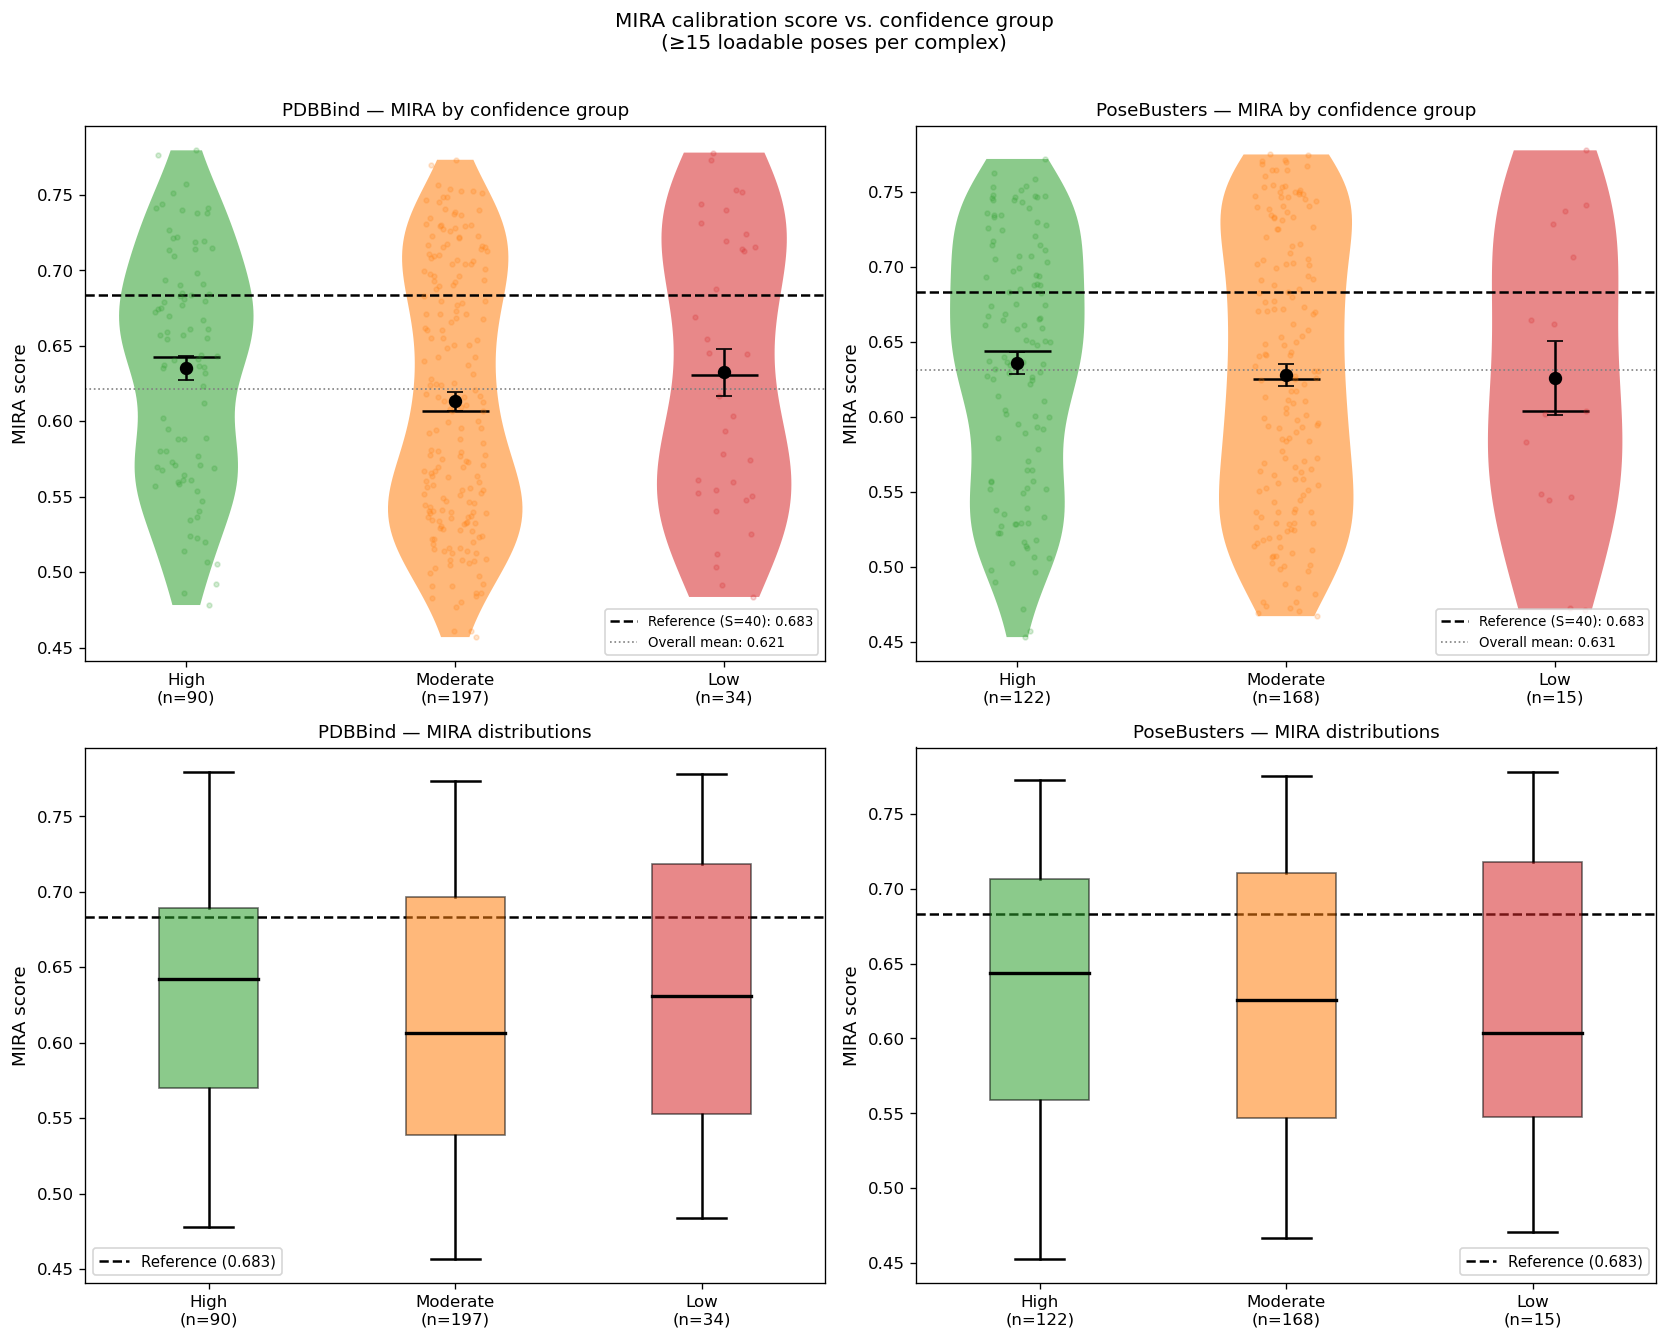

In [4]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, d in enumerate(DATASETS):
    mira_by_group = {}
    for name, fn, _ in GROUPS:
        m    = d['group_masks'][name]
        vals = d['mira_scores'][m]
        mira_by_group[name] = vals[np.isfinite(vals)]
    d['mira_by_group'] = mira_by_group

    data_v = [mira_by_group[g] for g in GROUP_NAMES]
    colors = [GROUP_COLORS[g] for g in GROUP_NAMES]

    # Mann-Whitney tests
    print(f"{d['label']} — Mann-Whitney U (one-sided, group > rest):")
    for name in GROUP_NAMES:
        grp  = mira_by_group[name]
        rest = np.concatenate([mira_by_group[o] for o in GROUP_NAMES if o != name])
        _, p = mannwhitneyu(grp, rest, alternative='greater')
        print(f"  {name} > rest: p={p:.3e}")
    print()

    # ── Top: violin ───────────────────────────────────────────────────────────
    ax = axes[0, col]
    vp = ax.violinplot(data_v, positions=np.arange(3), showmedians=True, showextrema=False)
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.55)
    vp['cmedians'].set_color('black')
    for i, (name, color) in enumerate(zip(GROUP_NAMES, colors)):
        d2 = mira_by_group[name]
        jitter = rng.uniform(-0.12, 0.12, size=len(d2))
        ax.scatter(i + jitter, d2, color=color, alpha=0.2, s=8, zorder=3)
        ax.errorbar(i, d2.mean(), yerr=d2.std() / np.sqrt(len(d2)),
                    fmt='o', color='black', capsize=5, ms=7, zorder=6)
    ax.axhline(REF_40, color='black', lw=1.5, ls='--',
               label=f'Reference (S=40): {REF_40:.3f}')
    ax.axhline(np.nanmean(d['mira_scores'][d['mask_keep']]), color='grey', lw=1, ls=':',
               label=f"Overall mean: {np.nanmean(d['mira_scores'][d['mask_keep']]):.3f}")
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([f"{g}\n(n={len(mira_by_group[g])})" for g in GROUP_NAMES], fontsize=10)
    ax.set_ylabel('MIRA score', fontsize=11)
    ax.set_title(f"{d['label']} — MIRA by confidence group", fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

    # ── Bottom: box plot ──────────────────────────────────────────────────────
    ax2 = axes[1, col]
    bp  = ax2.boxplot(data_v, positions=np.arange(3), patch_artist=True, widths=0.4,
                      medianprops=dict(color='black', lw=2),
                      whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                      flierprops=dict(marker='o', ms=3, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.55)
    ax2.axhline(REF_40, color='black', lw=1.5, ls='--', label=f'Reference ({REF_40:.3f})')
    ax2.set_xticks(np.arange(3))
    ax2.set_xticklabels([f"{g}\n(n={len(mira_by_group[g])})" for g in GROUP_NAMES], fontsize=10)
    ax2.set_ylabel('MIRA score', fontsize=11)
    ax2.set_title(f"{d['label']} — MIRA distributions", fontsize=11)
    ax2.legend(fontsize=9)

plt.suptitle('MIRA calibration score vs. confidence group\n'
             f'(≥{MIN_SAMPLES} loadable poses per complex)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/conf_group_mira_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation — Rank-1 Confidence vs. MIRA Score

Scatter of rank-1 confidence against MIRA score, plus a **decile-binned** mean MIRA per confidence bin
(analogous to the binned PB validity-rate analysis in `pb_filtering_analysis`).

PDBBind: Spearman ρ = +0.0524, p = 3.492e-01  (n=321)
PoseBusters: Spearman ρ = +0.0468, p = 4.149e-01  (n=305)


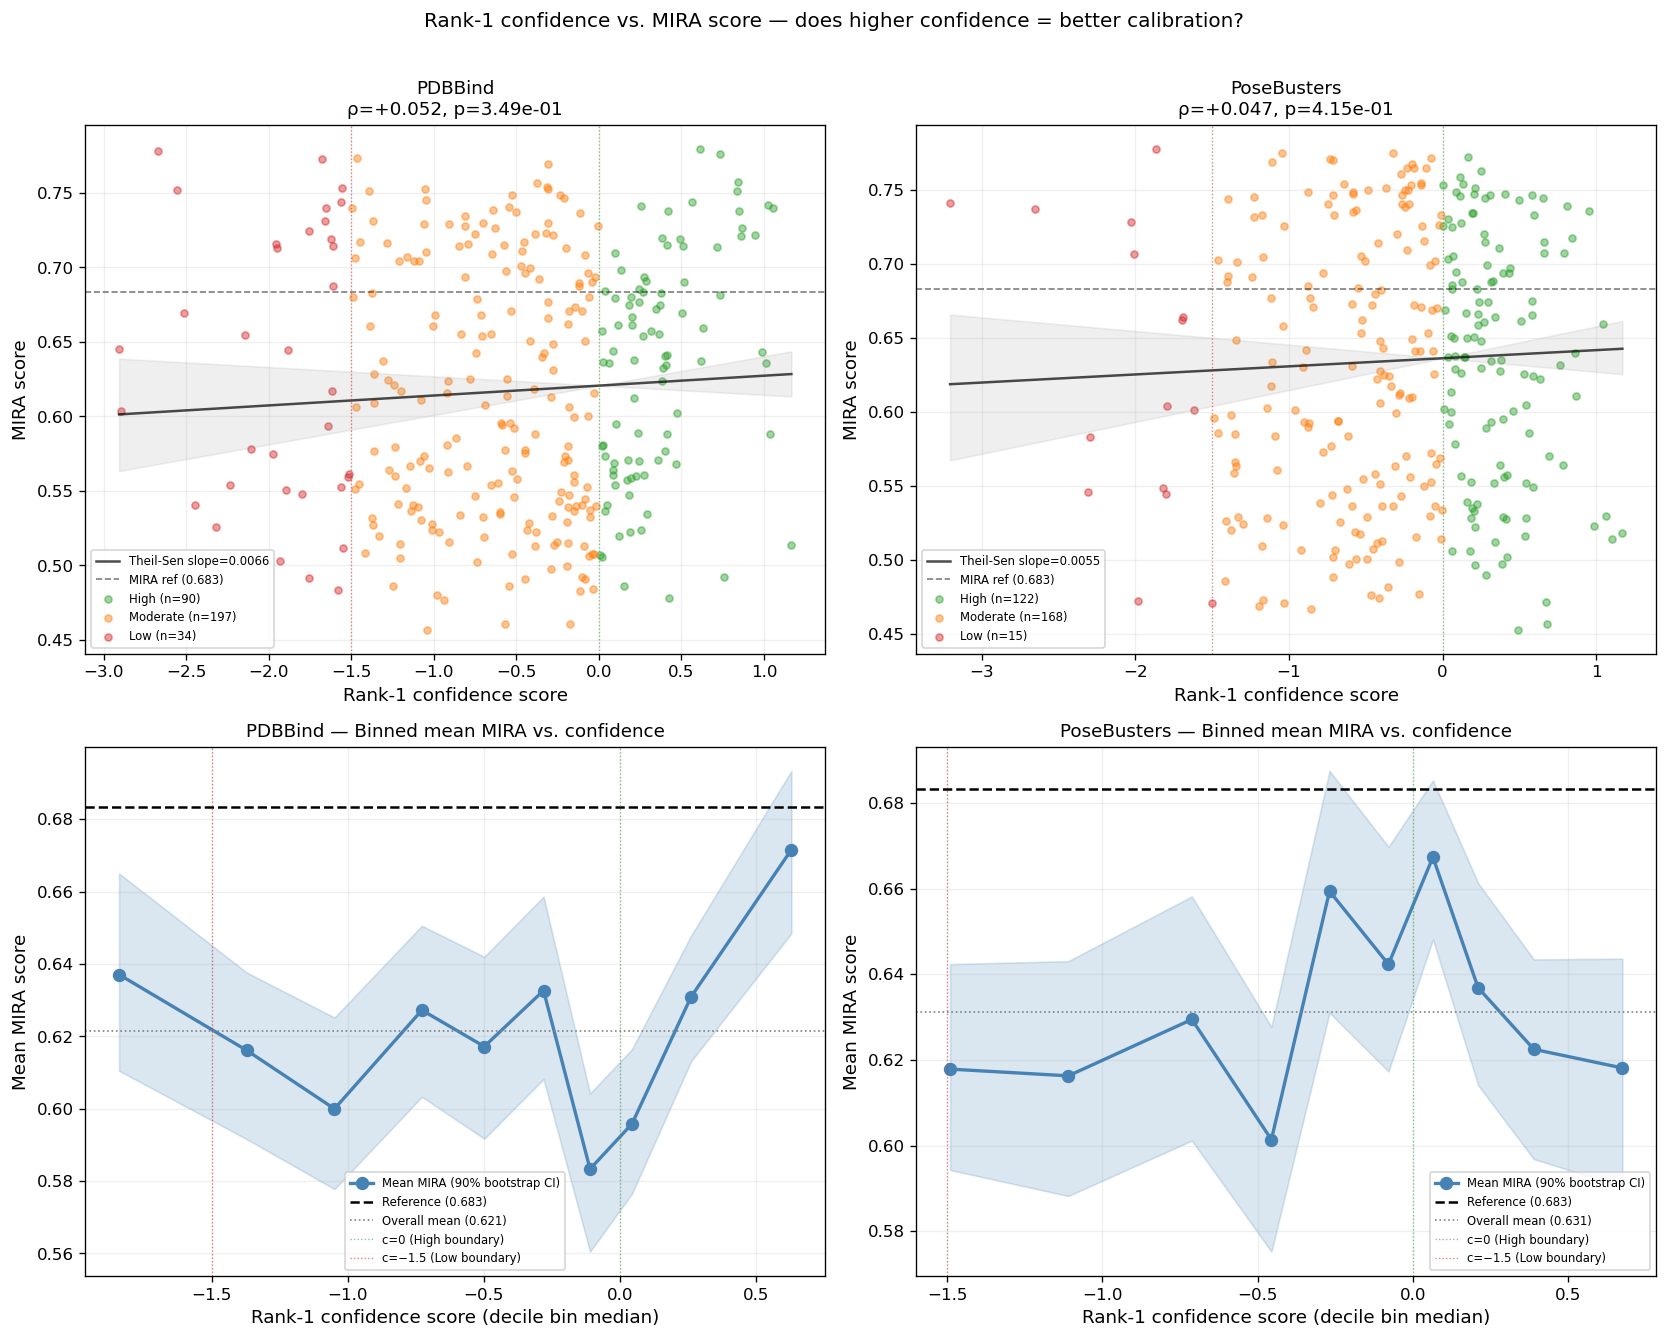

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, d in enumerate(DATASETS):
    valid_mask = d['mask_keep'] & np.isfinite(d['mira_scores'])
    c_vals = d['rank1_conf'][valid_mask]
    m_vals = d['mira_scores'][valid_mask]
    g_vals = np.array(['High' if c > 0 else ('Moderate' if c > -1.5 else 'Low')
                       for c in c_vals])
    d['c_vals'] = c_vals
    d['m_vals'] = m_vals
    d['g_vals'] = g_vals

    rho, p_rho = stats.spearmanr(c_vals, m_vals)
    d['rho'] = rho
    d['p_rho'] = p_rho
    print(f"{d['label']}: Spearman ρ = {rho:+.4f}, p = {p_rho:.3e}  (n={len(c_vals)})")

    # ── Top: scatter ──────────────────────────────────────────────────────────
    ax = axes[0, col]
    for name, _, color in GROUPS:
        idx = g_vals == name
        ax.scatter(c_vals[idx], m_vals[idx], color=color, alpha=0.45, s=18,
                   label=f'{name} (n={idx.sum()})')
    slope, intercept, lo, hi = theilslopes(m_vals, c_vals, 0.95)
    x_line = np.linspace(c_vals.min(), c_vals.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k-', lw=1.5, alpha=0.7,
            label=f'Theil-Sen slope={slope:.4f}')
    ax.fill_between(x_line, lo * x_line + intercept, hi * x_line + intercept,
                    color='grey', alpha=0.12)
    ax.axhline(REF_40, color='black', lw=1, ls='--', alpha=0.5,
               label=f'MIRA ref ({REF_40:.3f})')
    ax.axvline(0,    color='C2', lw=0.8, ls=':', alpha=0.6)
    ax.axvline(-1.5, color='C3', lw=0.8, ls=':', alpha=0.6)
    ax.set_xlabel('Rank-1 confidence score', fontsize=11)
    ax.set_ylabel('MIRA score', fontsize=11)
    ax.set_title(f"{d['label']}\nρ={rho:+.3f}, p={p_rho:.2e}", fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

    # ── Bottom: decile-binned mean MIRA ───────────────────────────────────────
    ax2 = axes[1, col]
    n_bins    = 10
    quantiles = np.unique(np.percentile(c_vals, np.linspace(0, 100, n_bins + 1)))
    bin_idx   = np.clip(np.digitize(c_vals, quantiles[:-1]) - 1, 0, n_bins - 1)
    bin_centers, bin_means, bin_lo, bin_hi = [], [], [], []
    for b in range(n_bins):
        bm = bin_idx == b
        if bm.sum() < 3:
            continue
        dv   = m_vals[bm]
        boot = np.array([rng.choice(dv, size=len(dv), replace=True).mean()
                         for _ in range(500)])
        bin_centers.append(np.median(c_vals[bm]))
        bin_means.append(dv.mean())
        bin_lo.append(np.percentile(boot, 5))
        bin_hi.append(np.percentile(boot, 95))
    bin_centers = np.array(bin_centers)
    bin_means   = np.array(bin_means)
    d['bin_centers'] = bin_centers
    d['bin_means']   = bin_means
    d['bin_lo']      = bin_lo
    d['bin_hi']      = bin_hi

    ax2.fill_between(bin_centers, bin_lo, bin_hi, alpha=0.2, color='steelblue')
    ax2.plot(bin_centers, bin_means, 'o-', color='steelblue', lw=2, ms=7,
             label='Mean MIRA (90% bootstrap CI)')
    ax2.axhline(REF_40, color='black', lw=1.5, ls='--',
                label=f'Reference ({REF_40:.3f})')
    ax2.axhline(np.nanmean(d['mira_scores'][d['mask_keep']]), color='grey', lw=1, ls=':',
                label=f"Overall mean ({np.nanmean(d['mira_scores'][d['mask_keep']]):.3f})")
    ax2.axvline(0,    color='C2', lw=0.8, ls=':', alpha=0.6, label='c=0 (High boundary)')
    ax2.axvline(-1.5, color='C3', lw=0.8, ls=':', alpha=0.6, label='c=−1.5 (Low boundary)')
    ax2.set_xlabel('Rank-1 confidence score (decile bin median)', fontsize=11)
    ax2.set_ylabel('Mean MIRA score', fontsize=11)
    ax2.set_title(f"{d['label']} — Binned mean MIRA vs. confidence", fontsize=11)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.2)

plt.suptitle('Rank-1 confidence vs. MIRA score — does higher confidence = better calibration?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/conf_vs_mira_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top-1 RMSD Accuracy by Confidence Group

Do higher-confidence complexes dock more accurately? This checks whether confidence is informative
for accuracy as well as distribution calibration.

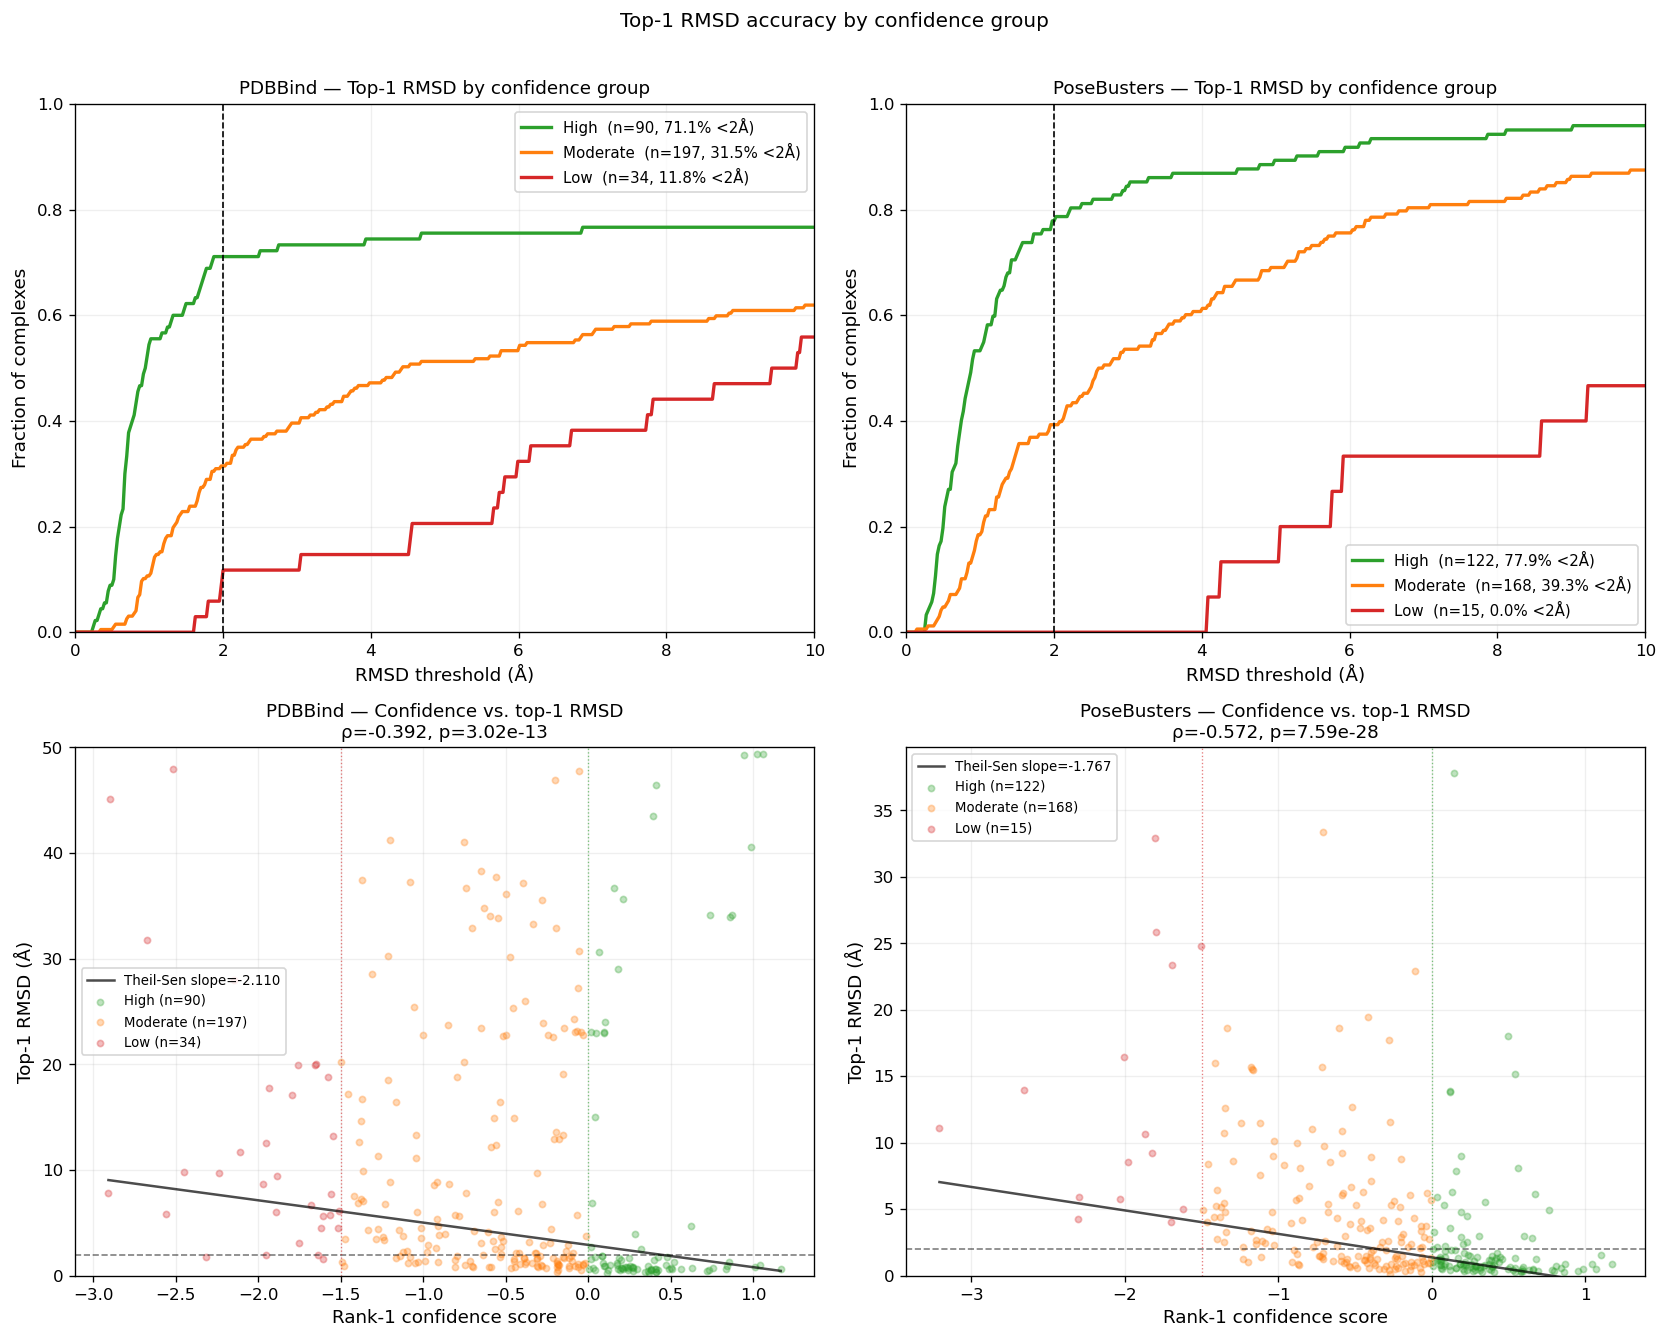

In [6]:
thresholds = np.linspace(0, 10, 400)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, d in enumerate(DATASETS):
    # ── Top: CDF per group ────────────────────────────────────────────────────
    ax = axes[0, col]
    for name, _, color in GROUPS:
        m    = d['group_masks'][name]
        rmsd = d['top1_rmsd'][m]
        rmsd = rmsd[np.isfinite(rmsd)]
        cdf  = np.array([(rmsd < t).mean() for t in thresholds])
        acc2 = (rmsd < 2).mean() * 100
        ax.plot(thresholds, cdf, color=color, lw=2,
                label=f'{name}  (n={len(rmsd)}, {acc2:.1f}% <2Å)')
    ax.axvline(2, color='black', ls='--', lw=1)
    ax.set_xlabel('RMSD threshold (Å)', fontsize=11)
    ax.set_ylabel('Fraction of complexes', fontsize=11)
    ax.set_title(f"{d['label']} — Top-1 RMSD by confidence group", fontsize=11)
    ax.set_xlim(0, 10); ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

    # ── Bottom: scatter confidence vs top-1 RMSD ─────────────────────────────
    ax2 = axes[1, col]
    rmsd_mask = d['mask_keep'] & np.isfinite(d['top1_rmsd'])
    c_r = d['rank1_conf'][rmsd_mask]
    r_r = d['top1_rmsd'][rmsd_mask]
    g_r = np.array(['High' if c > 0 else ('Moderate' if c > -1.5 else 'Low') for c in c_r])
    for name, _, color in GROUPS:
        idx = g_r == name
        ax2.scatter(c_r[idx], r_r[idx], color=color, alpha=0.3, s=14,
                    label=f'{name} (n={idx.sum()})')
    rho_r, p_r = stats.spearmanr(c_r, r_r)
    slope_r, intercept_r, _, _ = theilslopes(r_r, c_r, 0.95)
    x_line = np.linspace(c_r.min(), c_r.max(), 200)
    ax2.plot(x_line, slope_r * x_line + intercept_r, 'k-', lw=1.5, alpha=0.7,
             label=f'Theil-Sen slope={slope_r:.3f}')
    ax2.axhline(2, color='black', lw=1, ls='--', alpha=0.5)
    ax2.axvline(0,    color='C2', lw=0.8, ls=':', alpha=0.6)
    ax2.axvline(-1.5, color='C3', lw=0.8, ls=':', alpha=0.6)
    ax2.set_xlabel('Rank-1 confidence score', fontsize=11)
    ax2.set_ylabel('Top-1 RMSD (Å)', fontsize=11)
    ax2.set_title(f"{d['label']} — Confidence vs. top-1 RMSD\nρ={rho_r:+.3f}, p={p_r:.2e}",
                  fontsize=11)
    ax2.set_ylim(0, min(r_r.max() * 1.05, 50))
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.2)

plt.suptitle('Top-1 RMSD accuracy by confidence group', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/conf_group_rmsd_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. TARP Calibration by Confidence Group

**ECP above diagonal** = over-dispersed. **ECP below diagonal** = mode-collapsed.  

Pre-computed centroid TARP fractions (K=100 references) used for both benchmarks.

In [7]:
rng2 = np.random.default_rng(0)

for d in DATASETS:
    d['group_tarp'] = {}
    print(f"{d['label']}:")
    print(f"  {'Group':<14} {'N':>4}   {'MIRA mean':>10}   {'MIRA vs ref':>11}")
    print(f"  {'-'*46}")
    for name, _, _ in GROUPS:
        m    = d['group_masks'][name]
        f_g  = d['tarp_fracs'][m]
        ecp, alpha = ecp_from_fractions(f_g, n_bins=50)
        boot = bootstrap_ecp(f_g, n_bootstrap=500, rng=rng2)
        d['group_tarp'][name] = dict(n=m.sum(), f=f_g, ecp=ecp, alpha=alpha, boot=boot)
        mira_g = d['mira_scores'][m]
        mira_g = mira_g[np.isfinite(mira_g)]
        mira_mean = mira_g.mean()
        print(f"  {name:<14} {m.sum():>4}   {mira_mean:>10.4f}   {mira_mean - REF_40:>+11.4f}")
    f_all = d['tarp_fracs'][d['mask_keep']]
    ecp_a, alpha_a = ecp_from_fractions(f_all, n_bins=50)
    d['ecp_all']   = ecp_a
    d['alpha_all'] = alpha_a
    d['boot_all']  = bootstrap_ecp(f_all, n_bootstrap=500, rng=rng2)
    mira_all = d['mira_scores'][d['mask_keep']]
    mira_all = mira_all[np.isfinite(mira_all)]
    print(f"  {'All (filtered)':<14} {d['mask_keep'].sum():>4}   {mira_all.mean():>10.4f}   {mira_all.mean() - REF_40:>+11.4f}\n")


PDBBind:
  Group             N    MIRA mean   MIRA vs ref
  ----------------------------------------------
  High             90       0.6351       -0.0483
  Moderate        197       0.6131       -0.0702
  Low              34       0.6325       -0.0508
  All (filtered)  321       0.6213       -0.0620

PoseBusters:
  Group             N    MIRA mean   MIRA vs ref
  ----------------------------------------------
  High            122       0.6360       -0.0473
  Moderate        168       0.6280       -0.0554
  Low              15       0.6260       -0.0573
  All (filtered)  305       0.6311       -0.0522



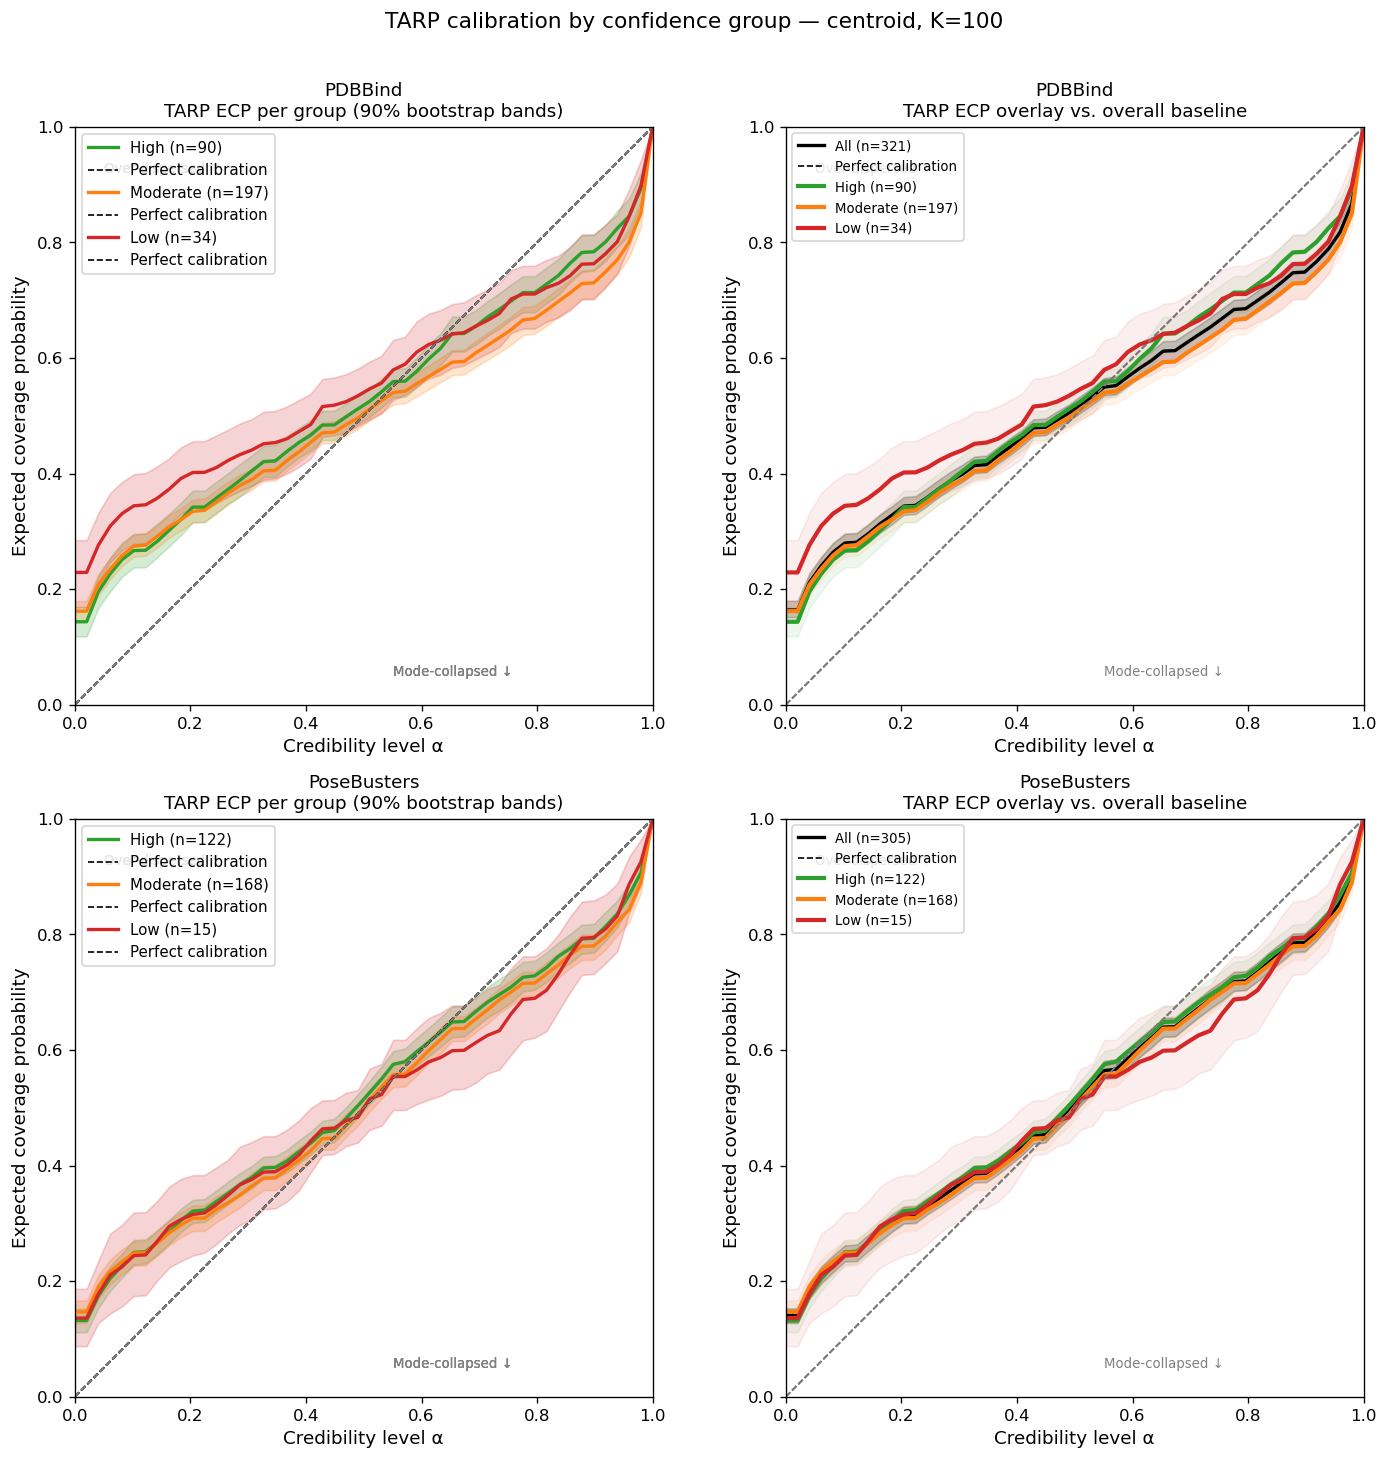

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for row, d in enumerate(DATASETS):

    # ── Col 0: ECP per group with bootstrap bands ────────────────────────────
    ax0 = axes[row, 0]
    for name, _, color in GROUPS:
        res = d['group_tarp'][name]
        plot_ecp(res['ecp'], res['alpha'], ax=ax0,
                 label=f"{name} (n={res['n']})",
                 color=color, bootstrap_ecps=res['boot'])
    ax0.plot([0, 1], [0, 1], 'grey', lw=1, ls='--')
    ax0.set_xlabel('Credibility level α', fontsize=11)
    ax0.set_ylabel('Expected coverage probability', fontsize=11)
    ax0.set_title(f"{d['label']}\nTARP ECP per group (90% bootstrap bands)", fontsize=11)
    ax0.set_xlim(0, 1); ax0.set_ylim(0, 1)
    ax0.set_aspect('equal')
    ax0.legend(fontsize=9, loc='upper left')

    # ── Col 1: overlay with overall baseline ─────────────────────────────────
    ax1 = axes[row, 1]
    plot_ecp(d['ecp_all'], d['alpha_all'], ax=ax1,
             label=f"All (n={d['mask_keep'].sum()})",
             color='black', bootstrap_ecps=d['boot_all'])
    for name, _, color in GROUPS:
        res = d['group_tarp'][name]
        ax1.plot(res['alpha'], res['ecp'], color=color, lw=2.5,
                 label=f"{name} (n={res['n']})")
        if res['boot'] is not None:
            blo = np.percentile(res['boot'], 5,  axis=0)
            bhi = np.percentile(res['boot'], 95, axis=0)
            ax1.fill_between(res['alpha'], blo, bhi, color=color, alpha=0.08)
    ax1.plot([0, 1], [0, 1], 'grey', lw=1, ls='--')
    ax1.set_xlabel('Credibility level α', fontsize=11)
    ax1.set_ylabel('Expected coverage probability', fontsize=11)
    ax1.set_title(f"{d['label']}\nTARP ECP overlay vs. overall baseline", fontsize=11)
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
    ax1.set_aspect('equal')
    ax1.legend(fontsize=8, loc='upper left')


plt.suptitle('TARP calibration by confidence group — centroid, K=100', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/conf_group_tarp_ecp.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Combined Summary Figure

4-row × 2-column panel with one column per benchmark:

| Row | Content |
|-----|---------|
| (A) | MIRA violin by confidence group |
| (B) | Binned mean MIRA vs. confidence |
| (C) | TARP ECP overlay |
| (D) | Top-1 accuracy (% <2Å) per group |

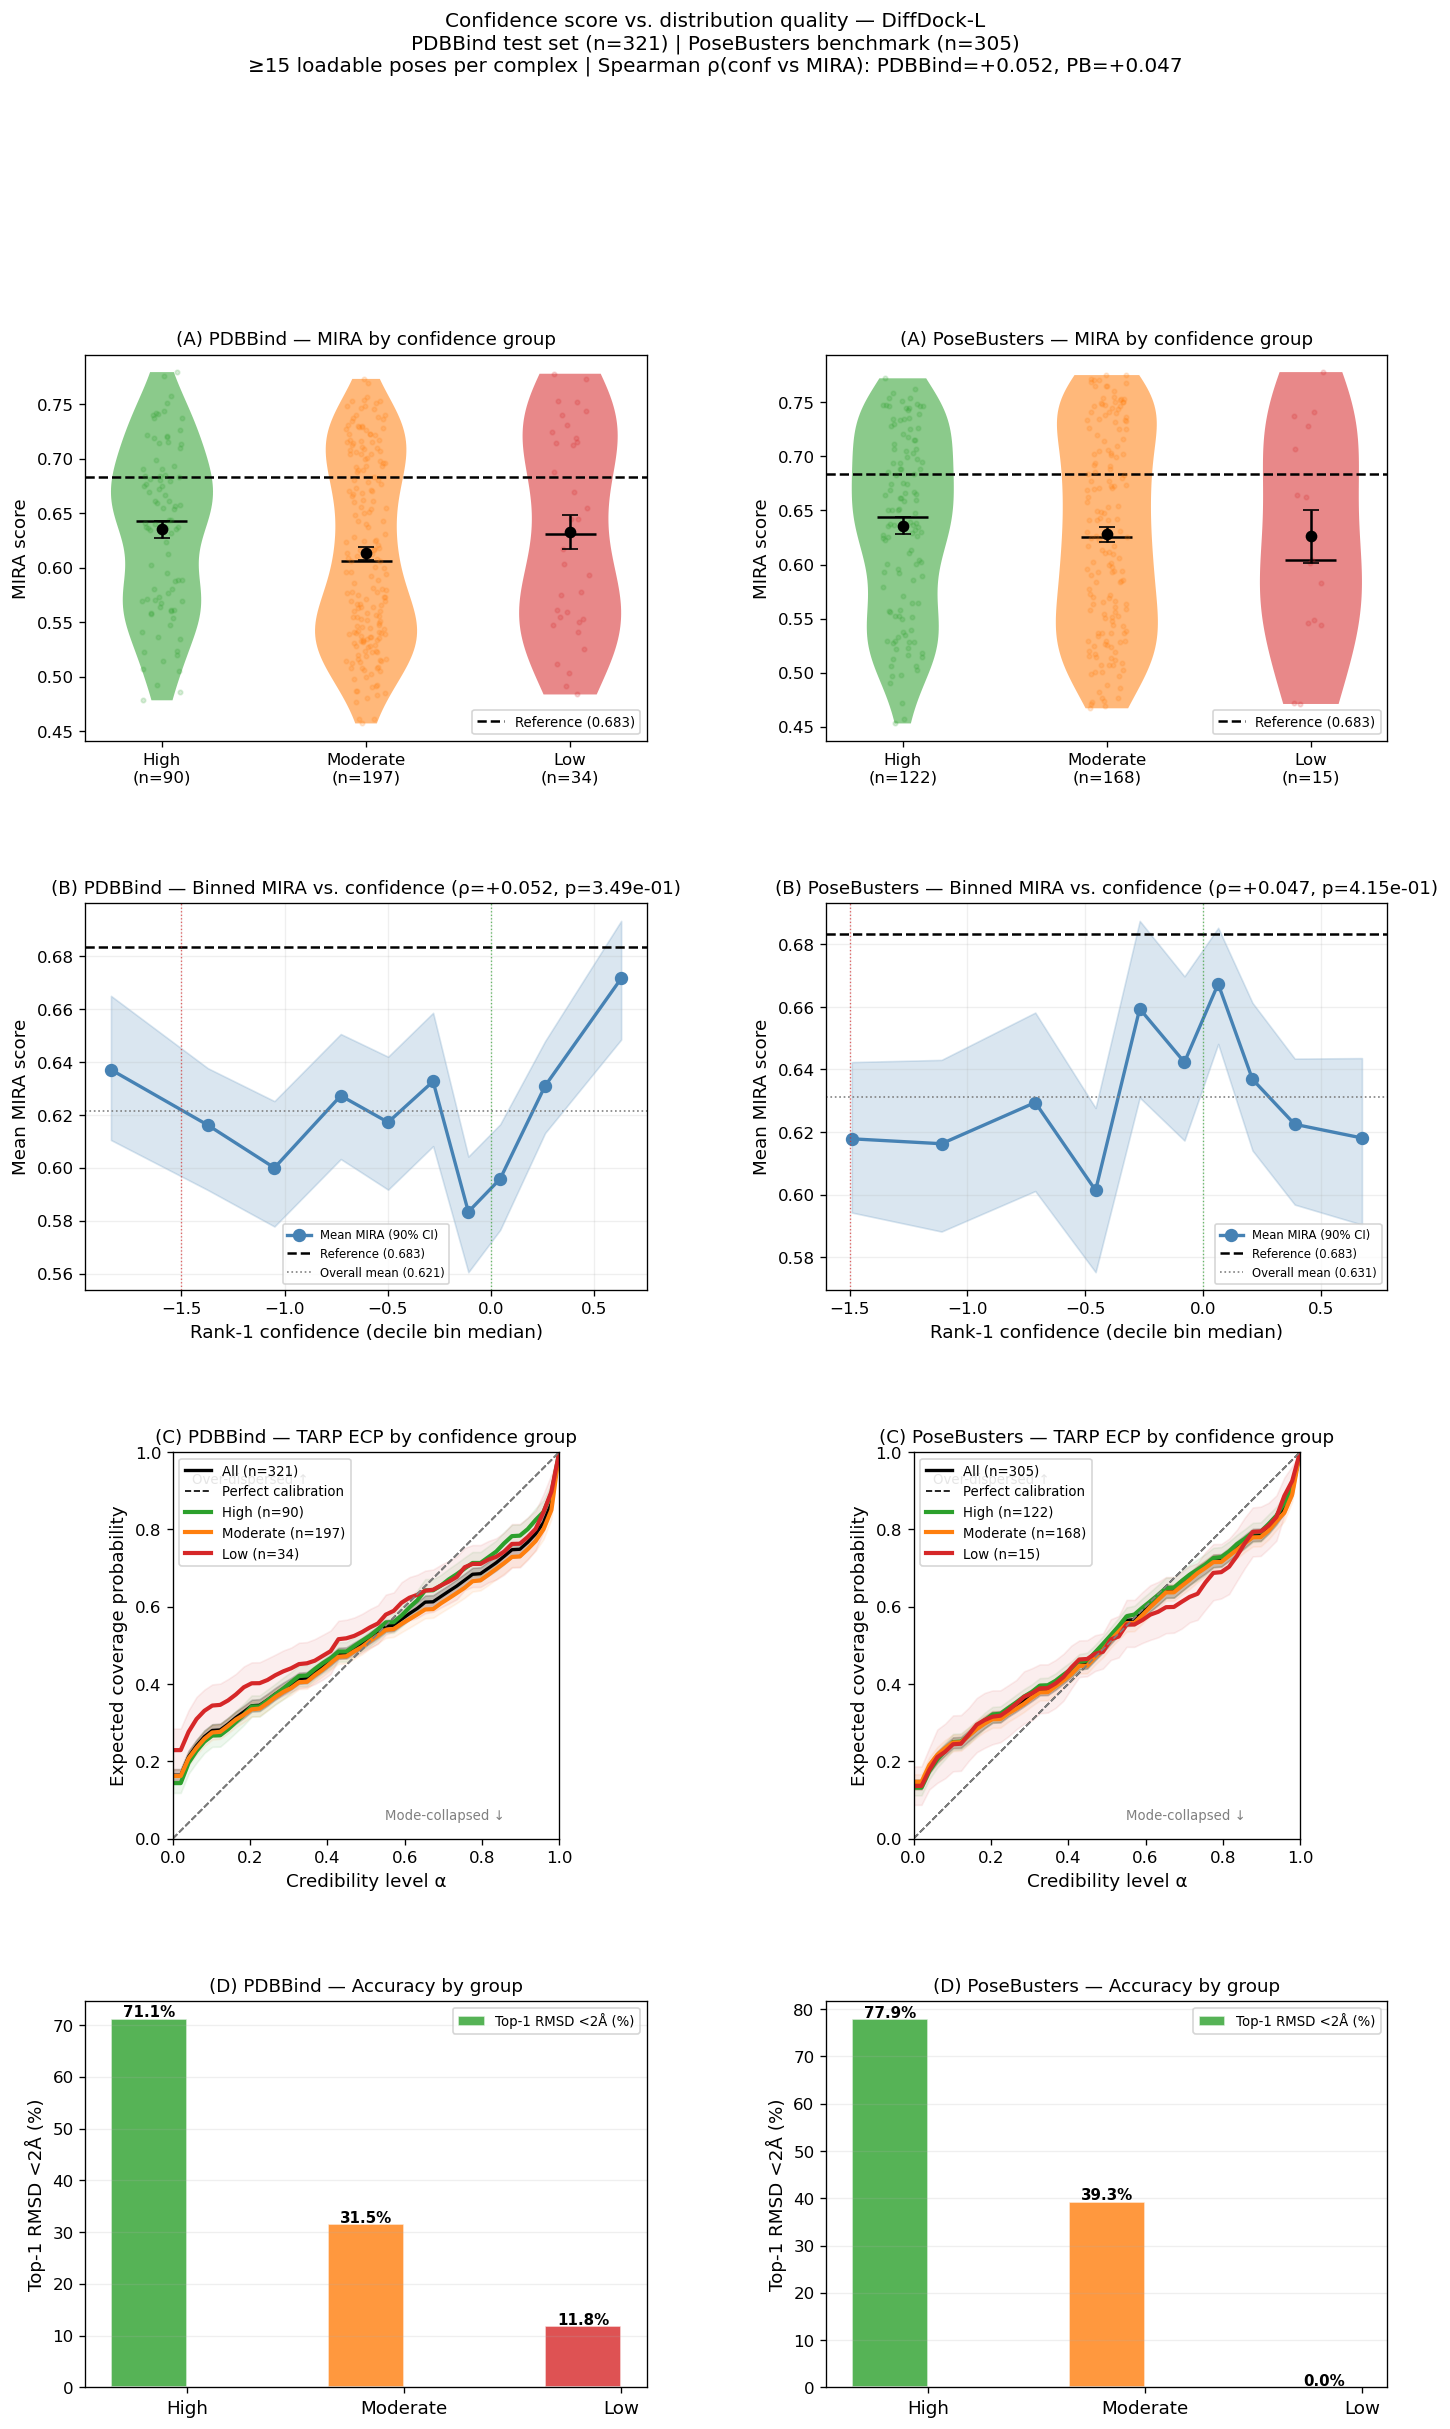

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
plt.subplots_adjust(hspace=0.42, wspace=0.32)

row_labels = ['(A)', '(B)', '(C)', '(D)']

for col, d in enumerate(DATASETS):
    colors = [GROUP_COLORS[g] for g in GROUP_NAMES]

    # ── (A) MIRA violin ───────────────────────────────────────────────────────
    ax = axes[0, col]
    data_v = [d['mira_by_group'][g] for g in GROUP_NAMES]
    vp = ax.violinplot(data_v, positions=np.arange(3), showmedians=True, showextrema=False)
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.55)
    vp['cmedians'].set_color('black')
    for i, (name, _, color) in enumerate(GROUPS):
        dv = d['mira_by_group'][name]
        jitter = np.random.default_rng(i + col).uniform(-0.1, 0.1, size=len(dv))
        ax.scatter(i + jitter, dv, color=color, alpha=0.18, s=7, zorder=3)
        ax.errorbar(i, dv.mean(), yerr=dv.std() / np.sqrt(len(dv)),
                    fmt='o', color='black', capsize=5, ms=6, zorder=6)
    ax.axhline(REF_40, color='black', lw=1.5, ls='--',
               label=f'Reference ({REF_40:.3f})')
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([f"{g}\n(n={len(d['mira_by_group'][g])})" for g in GROUP_NAMES],
                       fontsize=10)
    ax.set_ylabel('MIRA score', fontsize=11)
    ax.set_title(f"(A) {d['label']} — MIRA by confidence group", fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

    # ── (B) Binned MIRA ───────────────────────────────────────────────────────
    ax = axes[1, col]
    ax.fill_between(d['bin_centers'], d['bin_lo'], d['bin_hi'], alpha=0.2, color='steelblue')
    ax.plot(d['bin_centers'], d['bin_means'], 'o-', color='steelblue', lw=2, ms=7,
            label='Mean MIRA (90% CI)')
    ax.axhline(REF_40, color='black', lw=1.5, ls='--', label=f'Reference ({REF_40:.3f})')
    ax.axhline(np.nanmean(d['mira_scores'][d['mask_keep']]), color='grey', lw=1, ls=':',
               label=f"Overall mean ({np.nanmean(d['mira_scores'][d['mask_keep']]):.3f})")
    ax.axvline(0,    color='C2', lw=0.8, ls=':', alpha=0.7)
    ax.axvline(-1.5, color='C3', lw=0.8, ls=':', alpha=0.7)
    ax.set_xlabel('Rank-1 confidence (decile bin median)', fontsize=11)
    ax.set_ylabel('Mean MIRA score', fontsize=11)
    ax.set_title(f"(B) {d['label']} — Binned MIRA vs. confidence (ρ={d['rho']:+.3f}, p={d['p_rho']:.2e})",
                 fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

    # ── (C) TARP ECP overlay ──────────────────────────────────────────────────
    ax = axes[2, col]
    plot_ecp(d['ecp_all'], d['alpha_all'], ax=ax,
             label=f"All (n={d['mask_keep'].sum()})",
             color='black', bootstrap_ecps=d['boot_all'])
    for name, _, color in GROUPS:
        res = d['group_tarp'][name]
        ax.plot(res['alpha'], res['ecp'], color=color, lw=2.5,
                label=f"{name} (n={res['n']})")
        if res['boot'] is not None:
            blo = np.percentile(res['boot'], 5,  axis=0)
            bhi = np.percentile(res['boot'], 95, axis=0)
            ax.fill_between(res['alpha'], blo, bhi, color=color, alpha=0.08)
    ax.plot([0, 1], [0, 1], 'grey', lw=1, ls='--')
    ax.set_xlabel('Credibility level α', fontsize=11)
    ax.set_ylabel('Expected coverage probability', fontsize=11)
    ax.set_title(f"(C) {d['label']} — TARP ECP by confidence group", fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper left')

    # ── (D) Accuracy < 2Å per group ────────────────────────────────────────────
    ax = axes[3, col]
    x = np.arange(3); w = 0.35
    acc_2 = []
    for name, _, _ in GROUPS:
        m    = d['group_masks'][name]
        rmsd = d['top1_rmsd'][m]
        acc_2.append((rmsd[np.isfinite(rmsd)] < 2).mean() * 100)
    bars_acc = ax.bar(x - w/2, acc_2, w, color=colors, alpha=0.8,
                      label='Top-1 RMSD <2Å (%)', edgecolor='white')
    for bar, v in zip(bars_acc, acc_2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_NAMES, fontsize=11)
    ax.set_ylabel('Top-1 RMSD <2Å (%)', fontsize=11)
    ax.set_title(f"(D) {d['label']} — Accuracy by group", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle(
    'Confidence score vs. distribution quality — DiffDock-L\n'
    f'PDBBind test set (n={PDB["mask_keep"].sum()}) | '
    f'PoseBusters benchmark (n={PB["mask_keep"].sum()})\n'
    f'≥{MIN_SAMPLES} loadable poses per complex | '
    f'Spearman ρ(conf vs MIRA): PDBBind={PDB["rho"]:+.3f}, PB={PB["rho"]:+.3f}',
    fontsize=12, y=1.01
)
plt.savefig(f'{FIGURES}/conf_group_summary_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [10]:
import pandas as pd

for d in DATASETS:
    rows = []
    for name, _, _ in GROUPS:
        m    = d['group_masks'][name]
        c_r1 = d['rank1_conf'][m]
        mira = d['mira_scores'][m]; mira = mira[np.isfinite(mira)]
        rmsd = d['top1_rmsd'][m];   rmsd = rmsd[np.isfinite(rmsd)]
        res  = d['group_tarp'][name]
        boot_m = np.array([np.random.default_rng(42 + b).choice(mira, size=len(mira),
                           replace=True).mean() for b in range(500)])
        rows.append({
            'Group':               name,
            'N':                   int(m.sum()),
            'Rank-1 conf (med)':   f'{np.median(c_r1):.2f}',
            'Rank-1 conf (range)': f'[{c_r1.min():.2f}, {c_r1.max():.2f}]',
            'MIRA mean':           f'{mira.mean():.4f}',
            'MIRA 90% CI':         f'[{np.percentile(boot_m, 5):.4f}, {np.percentile(boot_m, 95):.4f}]',
            'MIRA vs ref':         f'{mira.mean() - REF_40:+.4f}',
            'Top-1 <2Å':           f'{(rmsd < 2).mean()*100:.1f}%',
            'Top-1 <5Å':           f'{(rmsd < 5).mean()*100:.1f}%',
        })
    m_all  = d['mask_keep']
    mira_a = d['mira_scores'][m_all]; mira_a = mira_a[np.isfinite(mira_a)]
    rmsd_a = d['top1_rmsd'][m_all];   rmsd_a = rmsd_a[np.isfinite(rmsd_a)]
    boot_a = np.array([np.random.default_rng(42+b).choice(mira_a, size=len(mira_a),
                       replace=True).mean() for b in range(500)])
    rows.append({
        'Group':               'All (filtered)',
        'N':                   int(m_all.sum()),
        'Rank-1 conf (med)':   f'{np.nanmedian(d["rank1_conf"][m_all]):.2f}',
        'Rank-1 conf (range)': f'[{np.nanmin(d["rank1_conf"][m_all]):.2f}, {np.nanmax(d["rank1_conf"][m_all]):.2f}]',
        'MIRA mean':           f'{mira_a.mean():.4f}',
        'MIRA 90% CI':         f'[{np.percentile(boot_a, 5):.4f}, {np.percentile(boot_a, 95):.4f}]',
        'MIRA vs ref':         f'{mira_a.mean() - REF_40:+.4f}',
        'Top-1 <2Å':           f'{(rmsd_a < 2).mean()*100:.1f}%',
        'Top-1 <5Å':           f'{(rmsd_a < 5).mean()*100:.1f}%',
    })
    print(f"\n{'='*70}")
    print(f"{d['label']}  (MIRA ref={REF_40:.4f}, Spearman ρ={d['rho']:+.4f}, p={d['p_rho']:.3e})")
    print('='*70)
    print(pd.DataFrame(rows).set_index('Group').to_string())


PDBBind  (MIRA ref=0.6833, Spearman ρ=+0.0524, p=3.492e-01)
                  N Rank-1 conf (med) Rank-1 conf (range) MIRA mean       MIRA 90% CI MIRA vs ref Top-1 <2Å Top-1 <5Å
Group                                                                                                                
High             90              0.28        [0.00, 1.17]    0.6351  [0.6231, 0.6499]     -0.0483     71.1%     75.6%
Moderate        197             -0.56      [-1.50, -0.01]    0.6131  [0.6034, 0.6233]     -0.0702     31.5%     51.3%
Low              34             -1.78      [-2.91, -1.51]    0.6325  [0.6071, 0.6614]     -0.0508     11.8%     20.6%
All (filtered)  321             -0.38       [-2.91, 1.17]    0.6213  [0.6138, 0.6295]     -0.0620     40.5%     54.8%

PoseBusters  (MIRA ref=0.6833, Spearman ρ=+0.0468, p=4.149e-01)
                  N Rank-1 conf (med) Rank-1 conf (range) MIRA mean       MIRA 90% CI MIRA vs ref Top-1 <2Å Top-1 <5Å
Group                                           